Exploratory Data Analysis of Viral Social Media Posts
📌 Description
This dataset captures viral social media trends across TikTok, Instagram, Twitter, and YouTube. It includes insights into popular hashtags, content types, user engagement levels, and regional impact. Ideal for trend analysis, sentiment modeling, and influencer marketing insights.
Datasource: https://www.kaggle.com/datasets/atharvasoundankar/viral-social-media-trends-and-engagement-analysis/data
🔹 Key Features: Covers multiple social media platforms 📱 Includes trending hashtags and content types 🔥 Provides engagement metrics for data-driven insights 📊 Useful for data visualization, sentiment analysis, and trend prediction 🚀
🏷️ Column Descriptions
Column Name Description Post_ID Unique identifier for each social media post Platform Social media platform (TikTok, Instagram, Twitter, YouTube) Hashtag Trending hashtag associated with the post Content_Type Type of content (Reel, Video, Post, Shorts, Tweet, etc.)
Problem Stattement: Understanding the key metrics infleuncing the social media content trends and users engagement across different platforms to get insights of the different content creators and marketers

## Import libraries

In [2]:
import pandas as pd #reading
import numpy as np #transformation
import matplotlib.pyplot as plt #visuals
import seaborn as sns #visual
import plotly.express as px #visuals
import plotly.graph_objects as go
from wordcloud import WordCloud
import cufflinks as cf

## Data collection

In [7]:
df= pd.read_csv('Viral_Social_Media_Trends.csv')


## Data Exploration

In [8]:
df.head(10)

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium
5,Post_6,Instagram,#Challenge,Shorts,Australia,1323566,136282,86979,47129,Low
6,Post_7,YouTube,#Comedy,Tweet,Japan,627233,84121,97973,32648,Medium
7,Post_8,YouTube,#Gaming,Shorts,UK,2066886,317502,45222,33638,High
8,Post_9,Twitter,#Education,Live Stream,India,2169523,496078,96041,30174,Medium
9,Post_10,TikTok,#Gaming,Shorts,India,3898384,8634,69378,42700,Low


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Post_ID           5000 non-null   object
 1   Platform          5000 non-null   object
 2   Hashtag           5000 non-null   object
 3   Content_Type      5000 non-null   object
 4   Region            5000 non-null   object
 5   Views             5000 non-null   int64 
 6   Likes             5000 non-null   int64 
 7   Shares            5000 non-null   int64 
 8   Comments          5000 non-null   int64 
 9   Engagement_Level  5000 non-null   object
dtypes: int64(4), object(6)
memory usage: 390.8+ KB


In [10]:
# Check for missing values
print(df.isnull().sum())

Post_ID             0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64


In [11]:
# Drop rows with missing values (if necessary)
df.dropna(inplace=True)

In [14]:
# Summary statistics
print(df.describe())


              Views          Likes        Shares      Comments
count  5.000000e+03    5000.000000   5000.000000   5000.000000
mean   2.494066e+06  251475.029800  50519.562000  24888.393800
std    1.459490e+06  144349.583384  29066.362671  14284.504319
min    1.266000e+03     490.000000     52.000000     18.000000
25%    1.186207e+06  126892.250000  25029.000000  12305.250000
50%    2.497373e+06  249443.000000  50839.500000  25004.000000
75%    3.759781e+06  373970.750000  75774.250000  37072.750000
max    4.999430e+06  499922.000000  99978.000000  49993.000000


/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_2437/994207107.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




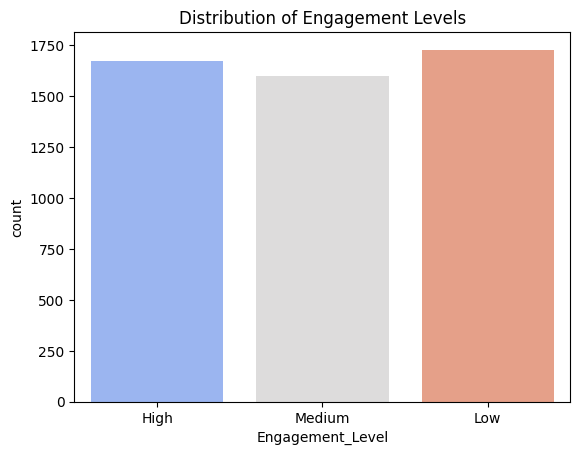

In [15]:
# Distribution of engagement levels
sns.countplot(data=df, x='Engagement_Level', palette='coolwarm')
plt.title("Distribution of Engagement Levels")
plt.show()

/var/folders/_f/952nnrtj2cqfx6j55v126fl80000gn/T/ipykernel_2437/2039970924.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




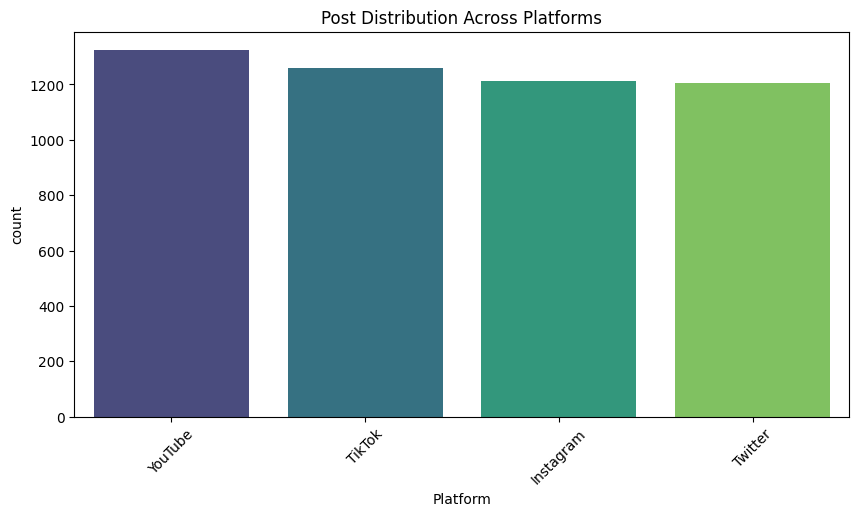

In [16]:
# Platform-based analysis
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Platform', order=df['Platform'].value_counts().index, palette='viridis')
plt.title("Post Distribution Across Platforms")
plt.xticks(rotation=45)
plt.show()

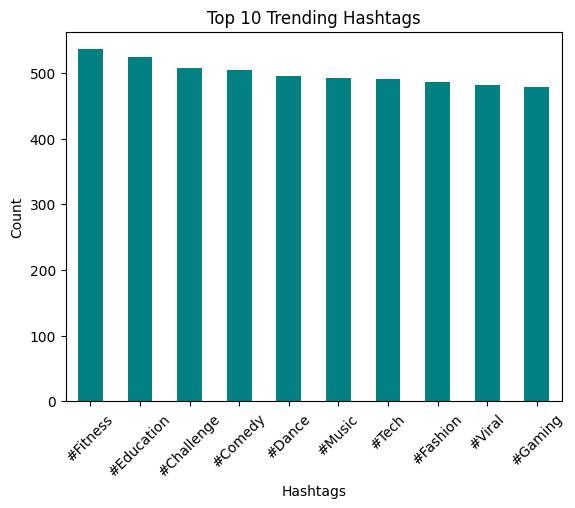

In [17]:
# Top 10 trending hashtags
top_hashtags = df['Hashtag'].value_counts().head(10)
top_hashtags.plot(kind='bar', color='teal')
plt.title("Top 10 Trending Hashtags")
plt.xlabel("Hashtags")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

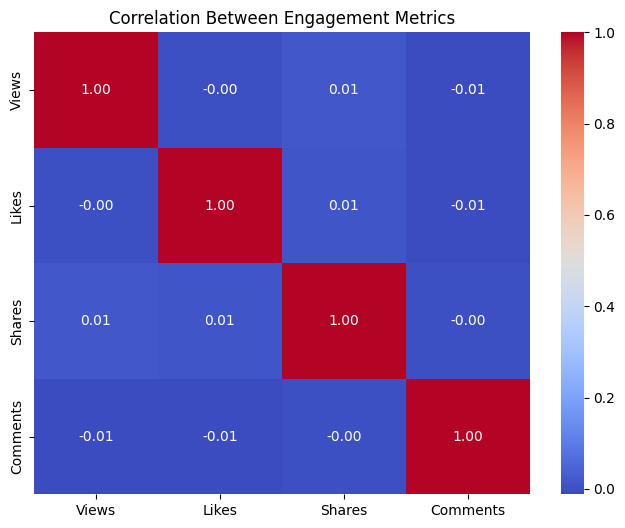

In [18]:
# Correlation matrix
numeric_cols = ['Views', 'Likes', 'Shares', 'Comments']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Between Engagement Metrics")
plt.show()

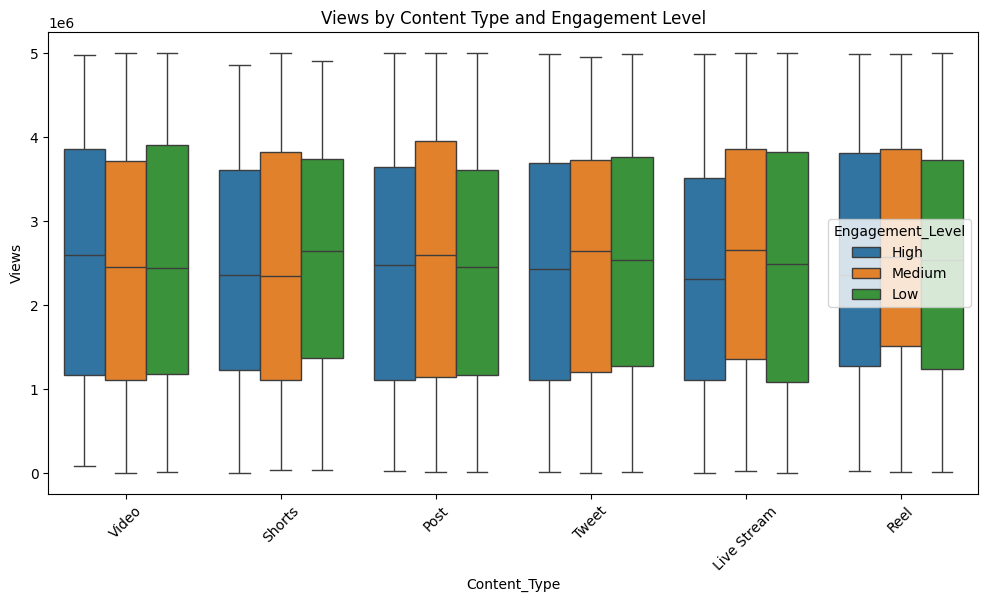

In [19]:
# Engagement level vs. content type
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Content_Type', y='Views', hue='Engagement_Level')
plt.xticks(rotation=45)
plt.title("Views by Content Type and Engagement Level")
plt.show()

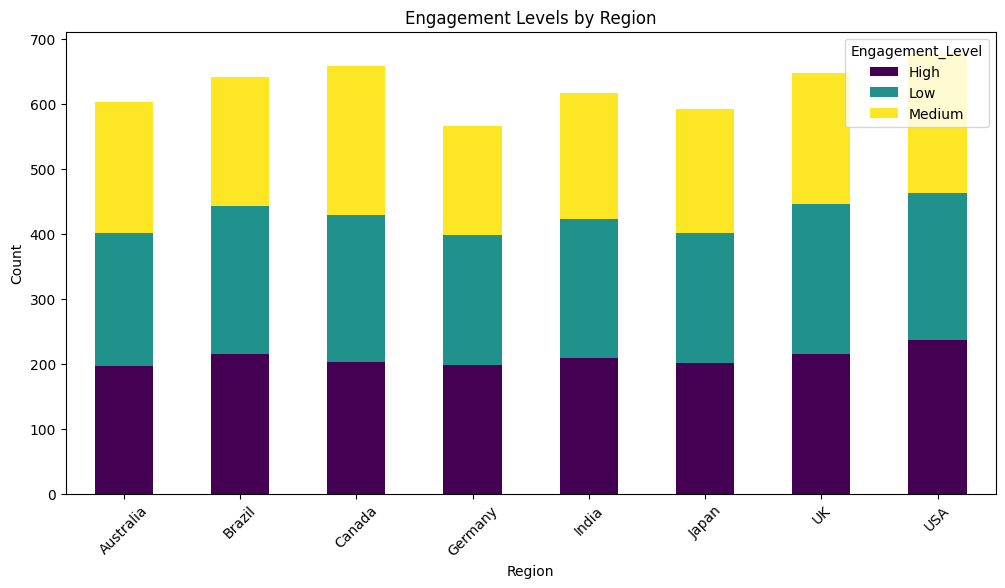

In [20]:
# Engagement level by region
grouped_region = df.groupby('Region')['Engagement_Level'].value_counts().unstack()
grouped_region.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
plt.title("Engagement Levels by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [21]:
# Top-performing posts by views
print("Top 10 Most Viewed Posts:")
print(df.sort_values(by='Views', ascending=False).head(10))

Top 10 Most Viewed Posts:
        Post_ID   Platform     Hashtag Content_Type   Region    Views   Likes  \
675    Post_676    YouTube      #Dance  Live Stream   Canada  4999430  419635   
2600  Post_2601    YouTube       #Tech  Live Stream  Germany  4999077  490971   
1841  Post_1842  Instagram      #Music         Reel    India  4997766  113205   
650    Post_651    Twitter  #Challenge         Post   Brazil  4997429   77831   
3603  Post_3604     TikTok      #Dance        Video   Brazil  4997284  394892   
2577  Post_2578    Twitter  #Education         Post    Japan  4996111  392899   
1881  Post_1882    YouTube  #Challenge         Post    Japan  4995973  392551   
1464  Post_1465    YouTube    #Fitness       Shorts    India  4995243  198754   
2008  Post_2009    YouTube     #Comedy        Video   Canada  4995038  103192   
1380  Post_1381    YouTube    #Fitness         Reel  Germany  4993673  462012   

      Shares  Comments Engagement_Level  
675    51709     19836              Low 